In [1]:
from astropy import table

import matplotlib.pyplot as plt
import numpy as np

from ugdatalab import (
    GaiaData,
    plot_raw_phase_folded_lightcurve,
    attach_flux_mean_magnitudes,
    attach_periodogram_periods,
    plot_lomb_scargle_periodogram,
    plot_period_mean_g,
    plot_vari_rrlyrae_period_comparison,
    plot_fourier_harmonic_fits,
    cross_validate_harmonics,
    fourier_fit,
    fourier_mean_magnitude,
    fourier_mean_magnitude_error,
    plot_fourier_cross_validation,
    plot_fourier_cv_normalized_residual_histograms,
    plot_fourier_cv_phase_comparison,
    plot_fourier_extrapolation,
    plot_mean_g_catalog_comparison,
)


The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
query = """
SELECT TOP 100 *
FROM gaiadr3.vari_rrlyrae
WHERE pf IS NOT NULL
  AND num_clean_epochs_g > 40
ORDER BY num_clean_epochs_g DESC
"""


## Sample Construction and Selection Effects

This notebook does **not** start from an unbiased RR Lyrae population. The Gaia query deliberately asks for `TOP 100` sources with `pf IS NOT NULL`, `num_clean_epochs_g > 40`, and then orders them by `num_clean_epochs_g DESC`. That choice is appropriate for a teaching notebook because it produces stars with many clean Gaia epochs and reliable catalog periods, which makes it easier to demonstrate period recovery and light-curve fitting on data that are already well measured.

The tradeoff is astrophysical representativeness. Ordering by the number of clean epochs preferentially selects stars with unusually good cadence and well-behaved photometry. Requiring a finite `pf` also excludes sources whose classification or period solution is less secure. The resulting sample is therefore biased toward stars for which one-period methods are likely to work well. Any recovery statistics derived below should be interpreted as performance on a **high-quality demonstration sample**, not as a population-level failure rate for Gaia RR Lyrae analysis in general.

In [3]:
rrlyrae = GaiaData(query, include_lightcurve=True)

rrlyrae.data[:10]


solution_id,source_id,pf,pf_error,p1_o,p1_o_error,epoch_g,epoch_g_error,epoch_bp,epoch_bp_error,epoch_rp,epoch_rp_error,epoch_rv,epoch_rv_error,int_average_g,int_average_g_error,int_average_bp,int_average_bp_error,int_average_rp,int_average_rp_error,average_rv,average_rv_error,peak_to_peak_g,peak_to_peak_g_error,peak_to_peak_bp,peak_to_peak_bp_error,peak_to_peak_rp,peak_to_peak_rp_error,peak_to_peak_rv,peak_to_peak_rv_error,metallicity,metallicity_error,r21_g,r21_g_error,r31_g,r31_g_error,phi21_g,phi21_g_error,phi31_g,phi31_g_error,num_clean_epochs_g,num_clean_epochs_bp,num_clean_epochs_rp,num_clean_epochs_rv,zp_mag_g,zp_mag_bp,zp_mag_rp,num_harmonics_for_p1_g,num_harmonics_for_p1_bp,num_harmonics_for_p1_rp,num_harmonics_for_p1_rv,reference_time_g,reference_time_bp,reference_time_rp,reference_time_rv,fund_freq1,fund_freq1_error,fund_freq2,fund_freq2_error,fund_freq1_harmonic_ampl_g,fund_freq1_harmonic_ampl_g_error,fund_freq1_harmonic_phase_g,fund_freq1_harmonic_phase_g_error,fund_freq1_harmonic_ampl_bp,fund_freq1_harmonic_ampl_bp_error,fund_freq1_harmonic_phase_bp,fund_freq1_harmonic_phase_bp_error,fund_freq1_harmonic_ampl_rp,fund_freq1_harmonic_ampl_rp_error,fund_freq1_harmonic_phase_rp,fund_freq1_harmonic_phase_rp_error,fund_freq1_harmonic_ampl_rv,fund_freq1_harmonic_ampl_rv_error,fund_freq1_harmonic_phase_rv,fund_freq1_harmonic_phase_rv_error,best_classification,g_absorption,g_absorption_error
,,,,,,d,d,d,d,d,d,d,d,,mag,mag,mag,mag,mag,km / s,km / s,mag,mag,mag,mag,mag,mag,km / s,km / s,dex,dex,,,,,rad,rad,rad,rad,,,,,mag,mag,mag,,,,,d,d,d,d,1 / d,1 / d,1 / d,1 / d,mag,mag,rad,rad,mag,mag,rad,rad,mag,mag,rad,rad,km / s,km / s,rad,rad,,mag,mag
int64,int64,float64,float64,float64,float64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,int16,int16,int16,float32,float32,float32,int16,int16,int16,int16,float64,float64,float64,float64,float64,float32,float64,float32,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,str4,float32,float32
375316653866487565,5284173207165634048,0.6754204135600004,1.145270016422728e-05,nan,nan,1664.7147255940913,1.6196564e-05,1664.725090176758,4.3462893e-05,1664.7448980260845,5.088851e-05,--,--,19.021461486816406,0.0015568832,19.218428,0.0108482,18.57285,0.007794851,--,--,0.23490465,0.005222299,0.25476402,0.03279039,0.19802193,0.020892723,--,--,-0.9399567,0.39976972,0.3227774,0.021646043,0.1224213,0.021695046,4.2703824,0.08953599,2.5574005,0.23331897,257,246,242,--,19.02329,19.22096,18.573446,3,2,2,--,1666.4768974530693,1666.4772118301444,1666.4773006462092,--,1.4805593374491128,2.5104959e-05,--,--,[0.10287211835384369 0.03320479393005371 0.012593737803399563 -- -- -- --\n -- -- -- -- -- -- -- -- --],[0.002026671776548028 0.002223402028903365 0.002232055412605405 -- -- --\n -- -- -- -- -- -- -- -- -- --],[0.21112152934074402 4.692625045776367 3.190765142440796 0.0 0.0 0.0 0.0\n 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0],[0.027860915288329124 0.06460897624492645 0.2089683562517166 -- -- -- --\n -- -- -- -- -- -- -- -- --],[0.11212261021137238 0.046277161687612534 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.018480001017451286 0.02448887564241886 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.45994314551353455 4.471524715423584 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0\n 0.0 0.0 0.0 0.0 0.0],[0.16694127023220062 0.6190136075019836 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.06839297711849213 0.04667317494750023 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],[0.011212748475372791 0.009829183109104633 -- -- -- -- -- -- -- -- -- --\n -- -- -- --],[6.272590160369873 4.2616424560546875 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0\n 0.0 0.0 0.0 0.0 0.0],[0.17579962313175201 0.2635345757007599 -- -- -- -- -- -- -- -- -- -- --\n -- -- --],

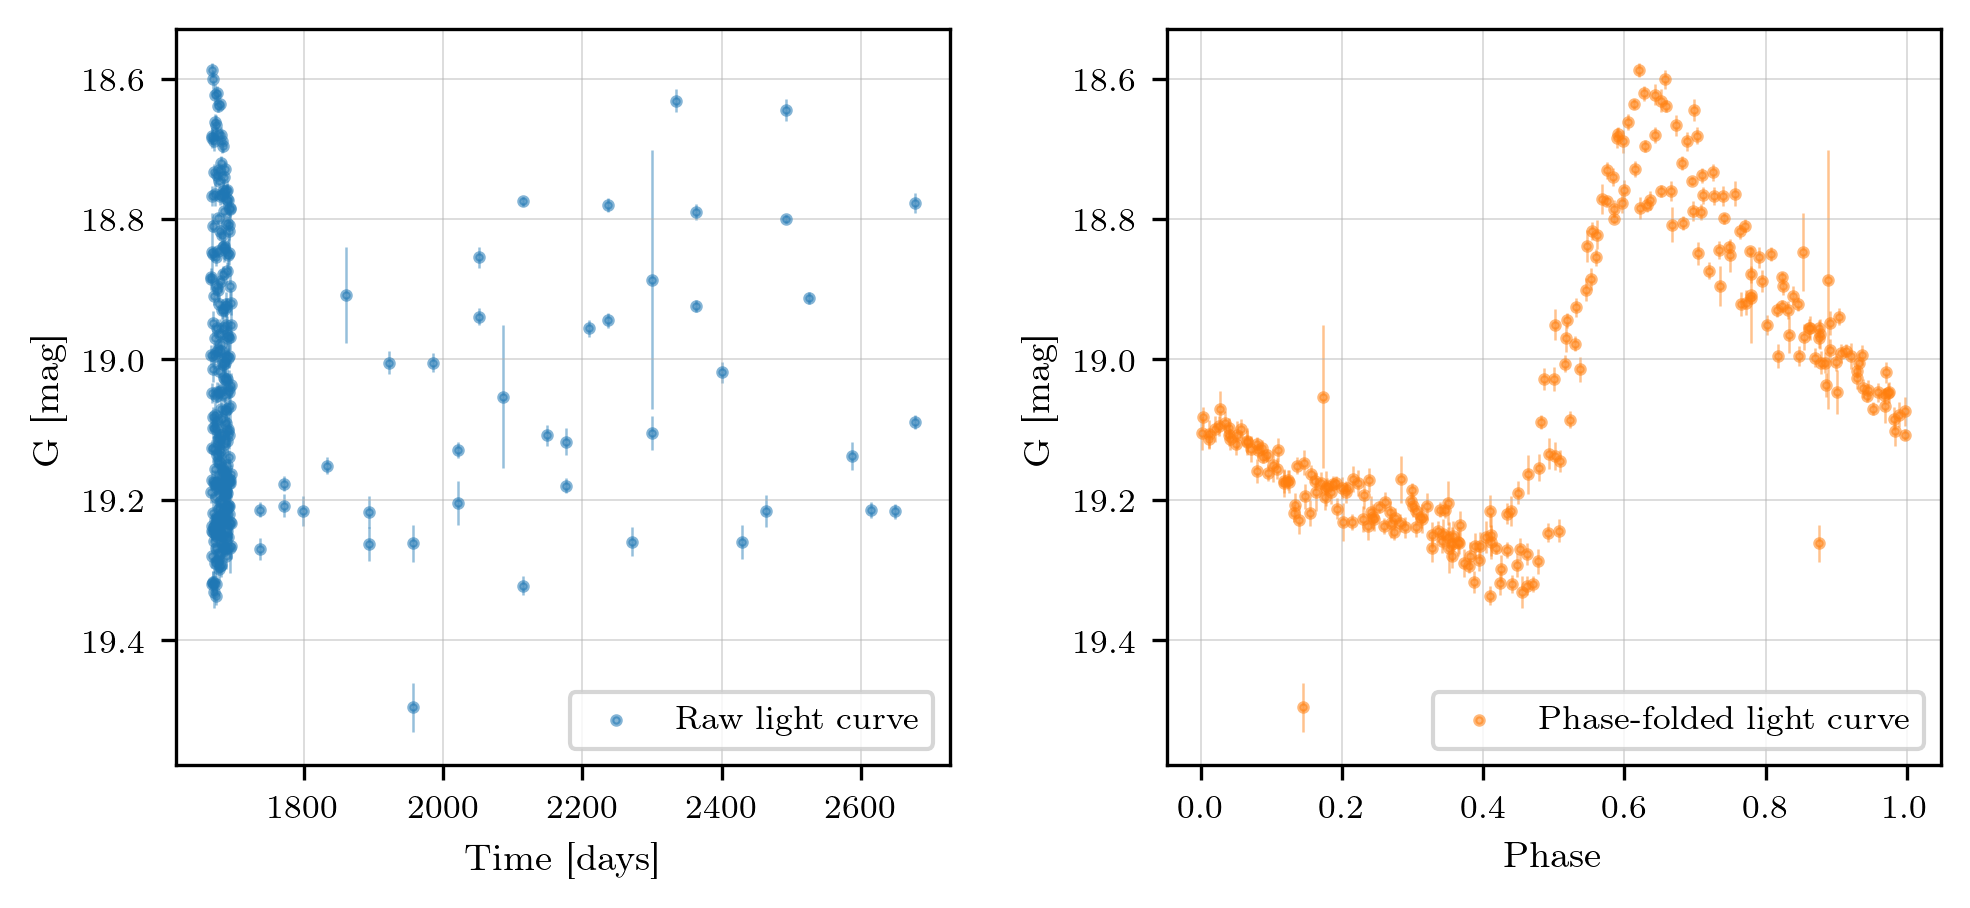

In [4]:
TARGET_ID = 4659759557323962752
lightcurves = attach_flux_mean_magnitudes(rrlyrae.lightcurves)

axes = plot_raw_phase_folded_lightcurve(TARGET_ID, lightcurves)
plt.show()


## Fluxes, Magnitudes, and Intensity Means

Gaia epoch photometry is fundamentally measured in **flux**, not magnitude. The helper `attach_flux_mean_magnitudes(...)` first propagates the epoch-level flux uncertainties into `g_transit_mag_err`, including the Gaia $G$-band zero-point term used by the repository. That is the correct place to introduce measurement uncertainty because the later Fourier fits are performed in magnitude space and therefore need per-epoch magnitude errors as weights.

The same helper also computes a direct per-source mean apparent magnitude by averaging the epoch fluxes, converting the mean flux back to magnitude, and propagating the flux error of the mean. This flux-space average is physically important: magnitudes are logarithmic, so a simple arithmetic average of magnitudes would not represent the average emitted light over the pulsation cycle. In variable-star work, the more meaningful quantity is the **intensity-averaged** magnitude, meaning the magnitude corresponding to the cycle-averaged flux.

That said, the direct flux mean is still only an estimator based on the **observed epochs**. If the cadence oversamples some pulsation phases and undersamples others, the direct flux mean can be biased relative to the true cycle-averaged flux. That is the astrophysical motivation for later fitting a periodic Fourier template and integrating that fitted model over a full cycle instead.

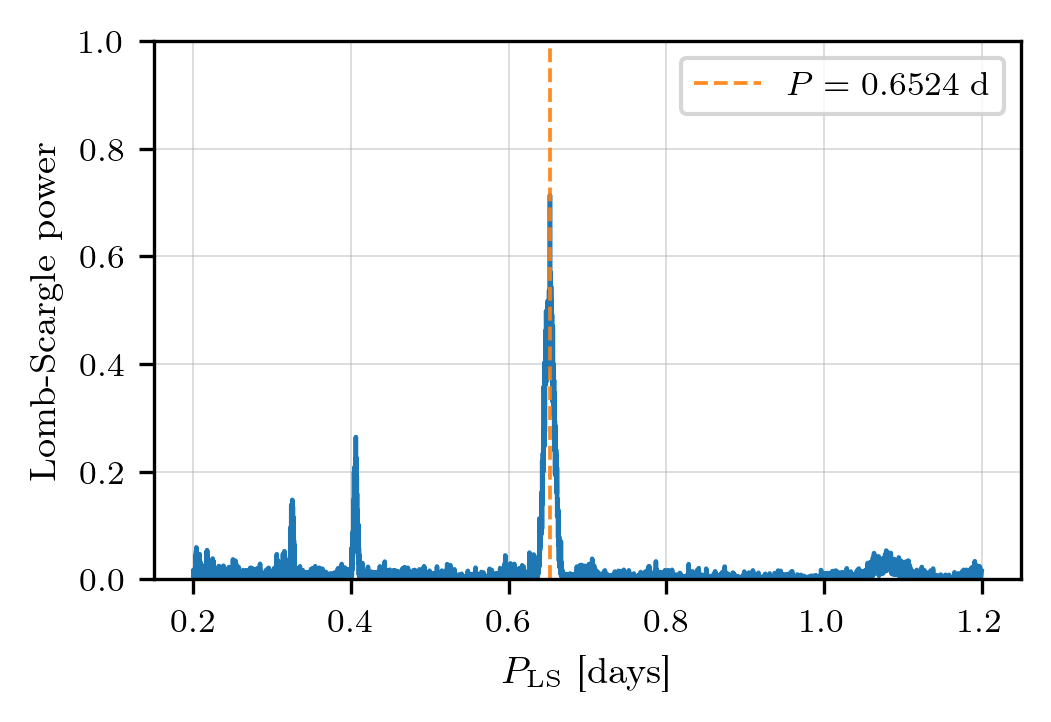

In [5]:
lightcurves = attach_periodogram_periods(lightcurves)

ax = plot_lomb_scargle_periodogram(TARGET_ID, lightcurves)
plt.show()


## Interpreting the Lomb-Scargle Periodogram

The Lomb-Scargle (L-S) periodogram is the standard period-finding tool used here because Gaia epoch photometry is **irregularly sampled**. A discrete Fourier transform assumes evenly spaced data, but the L-S formalism instead evaluates how well a sinusoidal model explains the light curve at each trial frequency even when the observing cadence is uneven. Physically, the dominant periodogram peak identifies the single frequency that best organizes the data into a coherent repeating pattern.

That makes the L-S periodogram a natural first step for RR Lyrae stars, whose light curves are dominated by stable pulsation periods. In this notebook, the quantity `period_ls` is therefore interpreted simply as the **strongest recovered single period** in the epoch photometry. For ordinary single-mode RRab and RRc stars, that is usually an appropriate summary. For RRd stars, Blazhko-modulated stars, or strongly aliased cadence, it is only the strongest **one-period approximation** to a more complicated signal.

The underlying method is standard, but the way the repository chooses the final best period is slightly more ad hoc than a textbook presentation. After computing the power spectrum, the code sorts periods by power, identifies peaks within `0.98 * max_power`, and then chooses the **longest** period among those near-maxima. That is a pragmatic tie-breaking rule for this teaching notebook, not a canonical part of Lomb-Scargle theory. It helps avoid unstable peak picking when several nearby periods have almost identical power, but it should be understood as an implementation detail rather than a universal best practice.

It is also important to be explicit about what the periodogram does **not** do here. The notebook uses the L-S periodogram only as a **point estimator** for the dominant period. It does not attempt a posterior over period, a false-alarm analysis, an alias map, or a multi-period decomposition. Questions about goodness of fit, harmonic complexity, and the limits of a one-period description are deferred to the later Fourier-model residual diagnostics.

In [6]:
source_ids, first_idx, counts = np.unique(
    lightcurves["source_id"],
    return_index=True,
    return_counts=True,
)
summary_rows = lightcurves[first_idx]

summary = table.Table(
    {
        "source_id": source_ids,
        "best_classification": summary_rows["best_classification"],
        "n_epochs": counts,
        "pf": summary_rows["pf"],
        "pf_error": summary_rows["pf_error"],
        "p1_o": summary_rows["p1_o"],
        "p1_o_error": summary_rows["p1_o_error"],
        "best_period": summary_rows["period_ls"],
        "mean_apparent_g": summary_rows["mean_g_transit_mag"],
        "mean_apparent_g_err": summary_rows["mean_g_transit_mag_err"],
        "int_average_g": summary_rows["int_average_g"],
        "int_average_g_error": summary_rows["int_average_g_error"],
    }
)



## Why Plot Period Against Apparent $G$?

The next summary table combines the recovered `period_ls`, the direct mean apparent magnitude, and the Gaia catalog mean magnitude for each source. Plotting period against the observed mean $G$ magnitude is **not** the same thing as fitting a period-luminosity relation. The vertical axis is an **apparent** magnitude, so it mixes together intrinsic luminosity, distance, extinction, and subclass differences.

That means the period-versus-mean-$G$ plot is best interpreted as a descriptive view of the selected sample rather than a physical inference step. It can reveal whether the sample spans a reasonable dynamic range in period and brightness, and it can sometimes expose obvious outliers or subclass clustering. But any astrophysical trend should be read cautiously because the sample is not distance-corrected and was selected for data quality rather than homogeneity.

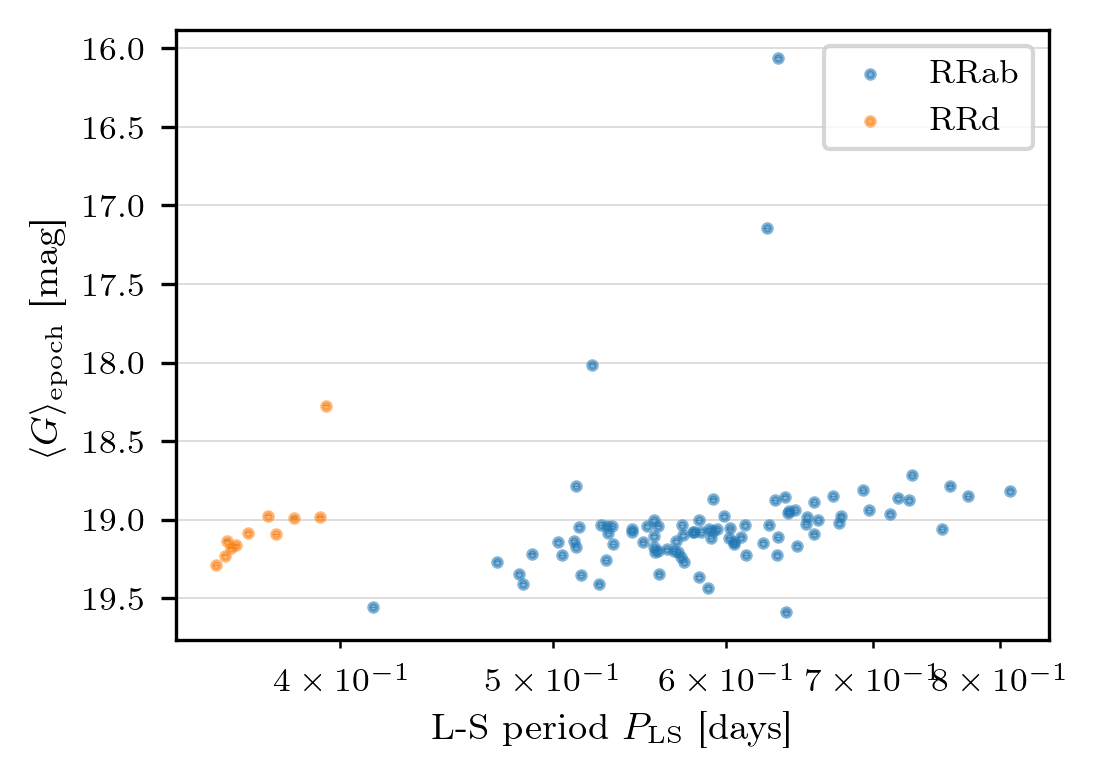

In [7]:
ax = plot_period_mean_g(summary)
plt.show()


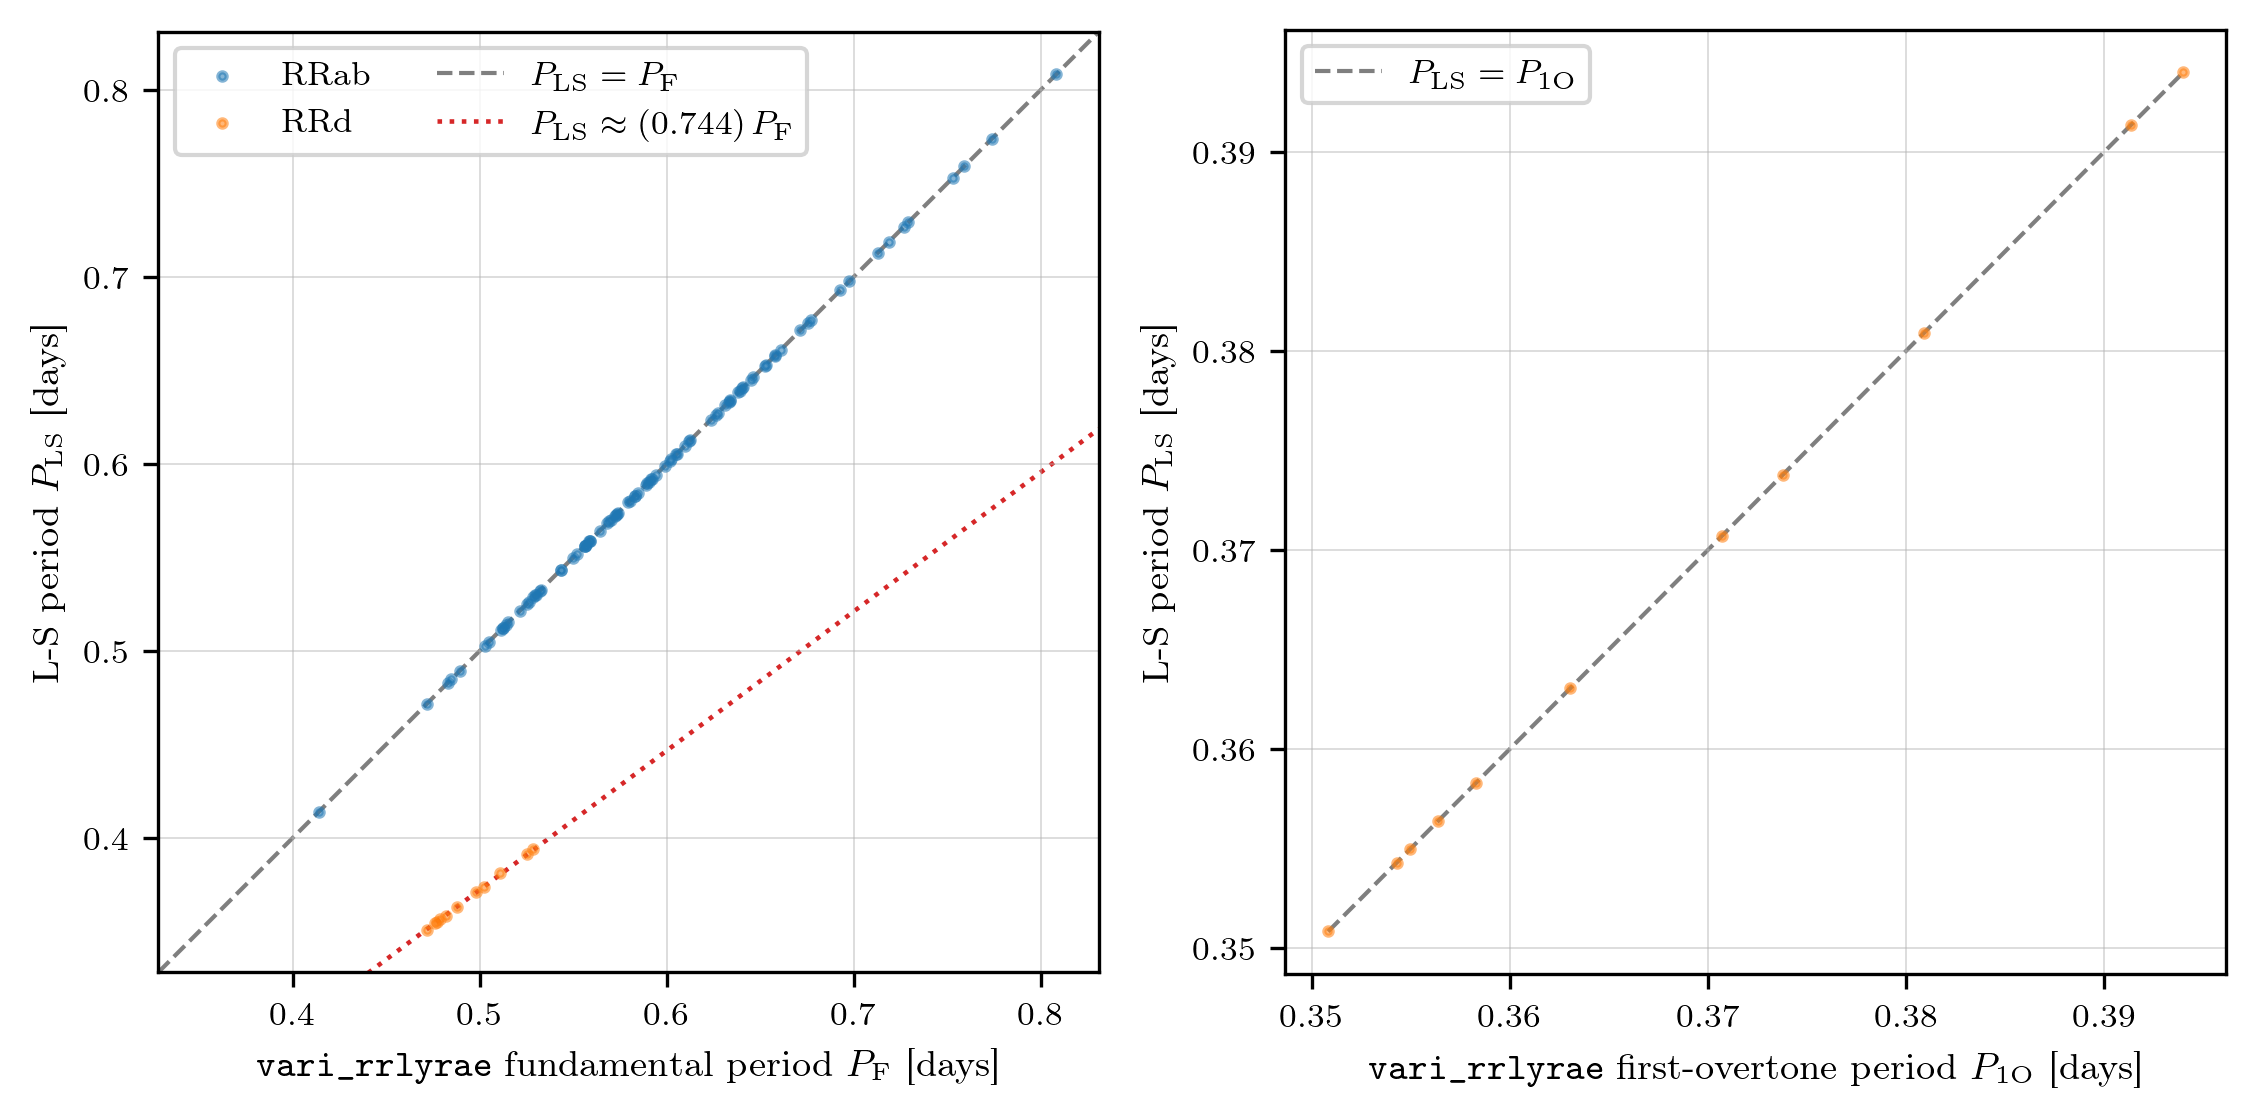

In [8]:
axes = plot_vari_rrlyrae_period_comparison(summary)
plt.show()


## Analysis and Discussion

The two-panel comparison addresses two different questions that need to be kept conceptually separate. The **left panel** asks whether the dominant period recovered from the epoch photometry agrees with the Gaia `vari_rrlyrae` **fundamental period** `pf`. The **right panel** asks a more specific RRd question: if the source is already known from Gaia to be a double-mode RR Lyrae star, does the recovered one-period solution align better with the Gaia **first-overtone** period `p1_o` than with the fundamental period?

Most stars lie very close to the 1:1 relation in the left panel: for these 100 light curves, the median absolute period difference is **0.0000 d**, the median absolute fractional difference is **0.00\%**, and **89/100** stars agree to better than **1\%**. That result is physically plausible for a deliberately high-quality sample selected to have many clean Gaia epochs. The notebook is not testing period recovery on a random or difficult population; it is testing it on a sample that is already strongly biased toward well-measured, regularly pulsating stars.

The largest mismatches are concentrated in the **RRd** subclass. That is the expected astrophysical failure mode of a one-period search. RRd stars pulsate simultaneously in the **fundamental** and **first-overtone** radial modes, so Gaia DR3 reports both `pf` and `p1_o`. A one-frequency Lomb-Scargle periodogram cannot decide “this star is double-mode”; it can only identify whichever single period dominates the power spectrum. In the present sample, the median ratio $P_{1\rm O}/P_{\rm F} = 0.744$ and the median ratio $P_{1\rm O}/P_{\rm LS} = 1.000$ together show that the strongest recovered single period for RRd stars is usually the **first-overtone** mode rather than the fundamental mode.

So the left-panel disagreement is not mainly evidence that the L-S method failed. It is instead a **mode-identification limitation** of the notebook pipeline. For RRab stars, where the dominant pulsation is the fundamental mode, the comparison to `pf` is the right benchmark and the agreement is very good. For RRd stars, the right-hand comparison is more physically meaningful because it reveals that the one-period solution is typically locking onto the first overtone.

This also motivates an important methodological caution: the notebook does **not** detect RRd stars from the epoch photometry alone. The current pipeline stores only one summary period per star, `period_ls`, and every downstream Fourier model is built around one adopted period. To establish that a star is genuinely double-mode from the time series alone, one would need a prewhitening workflow: fit the dominant mode, subtract it, recompute the periodogram on the residuals, identify a second independent peak, and check whether the two periods satisfy the characteristic RRd ratio $P_1/P_0 \approx 0.74$--$0.75$. The markdown below describes that astrophysical workflow, but the notebook itself does not yet implement it.

Some of the formal magnitude-domain uncertainties are also very small. That is not surprising for bright Gaia sources: epoch-level $G$ errors are small, and direct flux-space mean errors shrink roughly like a standard error on the mean flux. Once the notebook fixes a period $P$ and harmonic order $K$, the Fourier model is linear in its coefficient vector, so the remaining formal fit uncertainty comes only from propagating those photometric errors through weighted least squares. Small Fourier error bars therefore mean that the coefficients are tightly constrained **within the adopted fixed-$(P,K)$ model**, not that every astrophysical uncertainty has been captured. If the residual scatter remains larger than those formal errors, the correct interpretation is model inadequacy, period ambiguity, or genuine astrophysical structure beyond a fixed one-period template.

A practical **RRd-identification workflow** using Gaia epoch photometry would therefore be:

1. Compute the full Lomb-Scargle periodogram and record the dominant period $P_A$.
2. Fit a one-period Fourier model at $P_A$ and subtract it from the light curve (**prewhitening**).
3. Recompute the periodogram on the residuals and search for a second independent period $P_B$.
4. Reject peaks that are consistent with simple harmonics or aliases of the first solution; a true RRd candidate should show two independent modes rather than just the harmonic structure of a non-sinusoidal RRab light curve.
5. Identify the longer period as the candidate fundamental mode $P_0$ and the shorter period as the candidate first overtone $P_1$, then check whether $P_1/P_0 \approx 0.74$--$0.75$.
6. Fold the data or residuals on both periods to verify that each mode removes genuine structure from the light curve.
7. If Gaia catalog information is available, compare against `best_classification`, `pf`, and `p1_o` as an external consistency check.

References: Clementini et al. 2023, *A\&A*, **674**, A18; Nemec & Moskalik 2024, *Living Reviews in Solar Physics*, **21**, 1.

## Why Fourier Harmonics Work for RR Lyrae Light Curves

RR Lyrae light curves are periodic but they are usually **not sinusoidal**. A pure sinusoid can reproduce only the gross periodicity. Real RRab stars in particular show a steep rise to maximum light, a slower decline, and visibly asymmetric shapes. Those departures from a sinusoid naturally generate harmonic structure in Fourier space, which is why a finite Fourier series is a standard descriptive model for pulsating-variable light curves.

In this notebook, the Fourier model is used as a **fixed-period shape model**. The period is assumed known first, and then the harmonic order $K$ controls how much shape complexity is allowed. Low $K$ produces smooth, nearly sinusoidal curves. Higher $K$ allows sharper maxima, more asymmetric profiles, and more detailed shape structure. The specific trial set `K = [1, 3, 5, 7, 9]` shown below is a pedagogical grid: it is chosen to make the transition from underfitting to increasingly flexible fits visually obvious. It is not itself an optimized or exhaustive model-selection procedure.

Once the angular frequency $\omega = 2\pi/P$ is fixed, the Fourier model is **linear** in the remaining coefficients. Writing the model at an observation time $t_i$ gives

$$
y_i = A_0 + \sum_{k=1}^K \left[a_k \sin(k\omega t_i) + b_k \cos(k\omega t_i)\right],
$$

where $y_i$ is the measured flux or magnitude at time $t_i$. We can rewrite this as a dot product,

$$
y_i = \mathbf{x}_i^\top \boldsymbol{\beta},
$$

with

$$
\mathbf{x}_i = \begin{bmatrix}
1,
\cos(\omega t_i),
\sin(\omega t_i),
\cos(2\omega t_i),
\sin(2\omega t_i),
\ldots,
\cos(K\omega t_i),
\sin(K\omega t_i)
\end{bmatrix},
\qquad
\boldsymbol{\beta} = \begin{bmatrix}
A_0,
b_1,
a_1,
b_2,
a_2,
\ldots,
b_K,
a_K
\end{bmatrix}.
$$

Stacking all $N$ observations together gives the matrix equation

$$
\mathbf{y} = X\boldsymbol{\beta},
$$

where the design matrix $X$ has one row per observation time. So once $P$ is fixed, fitting the Fourier series reduces to a weighted linear least-squares problem for the coefficient vector $\boldsymbol{\beta}$.

## Exploring Harmonic Complexity by Eye

Before selecting an optimal harmonic order statistically, the notebook first shows a sequence of fits with manually chosen values `K = [1, 3, 5, 7, 9]`. This is an interpretive step rather than an optimization step. The purpose is to build intuition for how additional harmonics change the fitted morphology.

For RR Lyrae stars, increasing $K$ allows the model to represent sharper maxima, more asymmetric rise-and-fall behavior, and increasingly fine structure in the phase-folded light curve. The sequence therefore gives a direct visual demonstration of the tradeoff between **underfitting** and **shape flexibility**. It should not be mistaken for a proof that these are the only relevant values of $K$; they are chosen because they make the transition in model complexity easy to see.

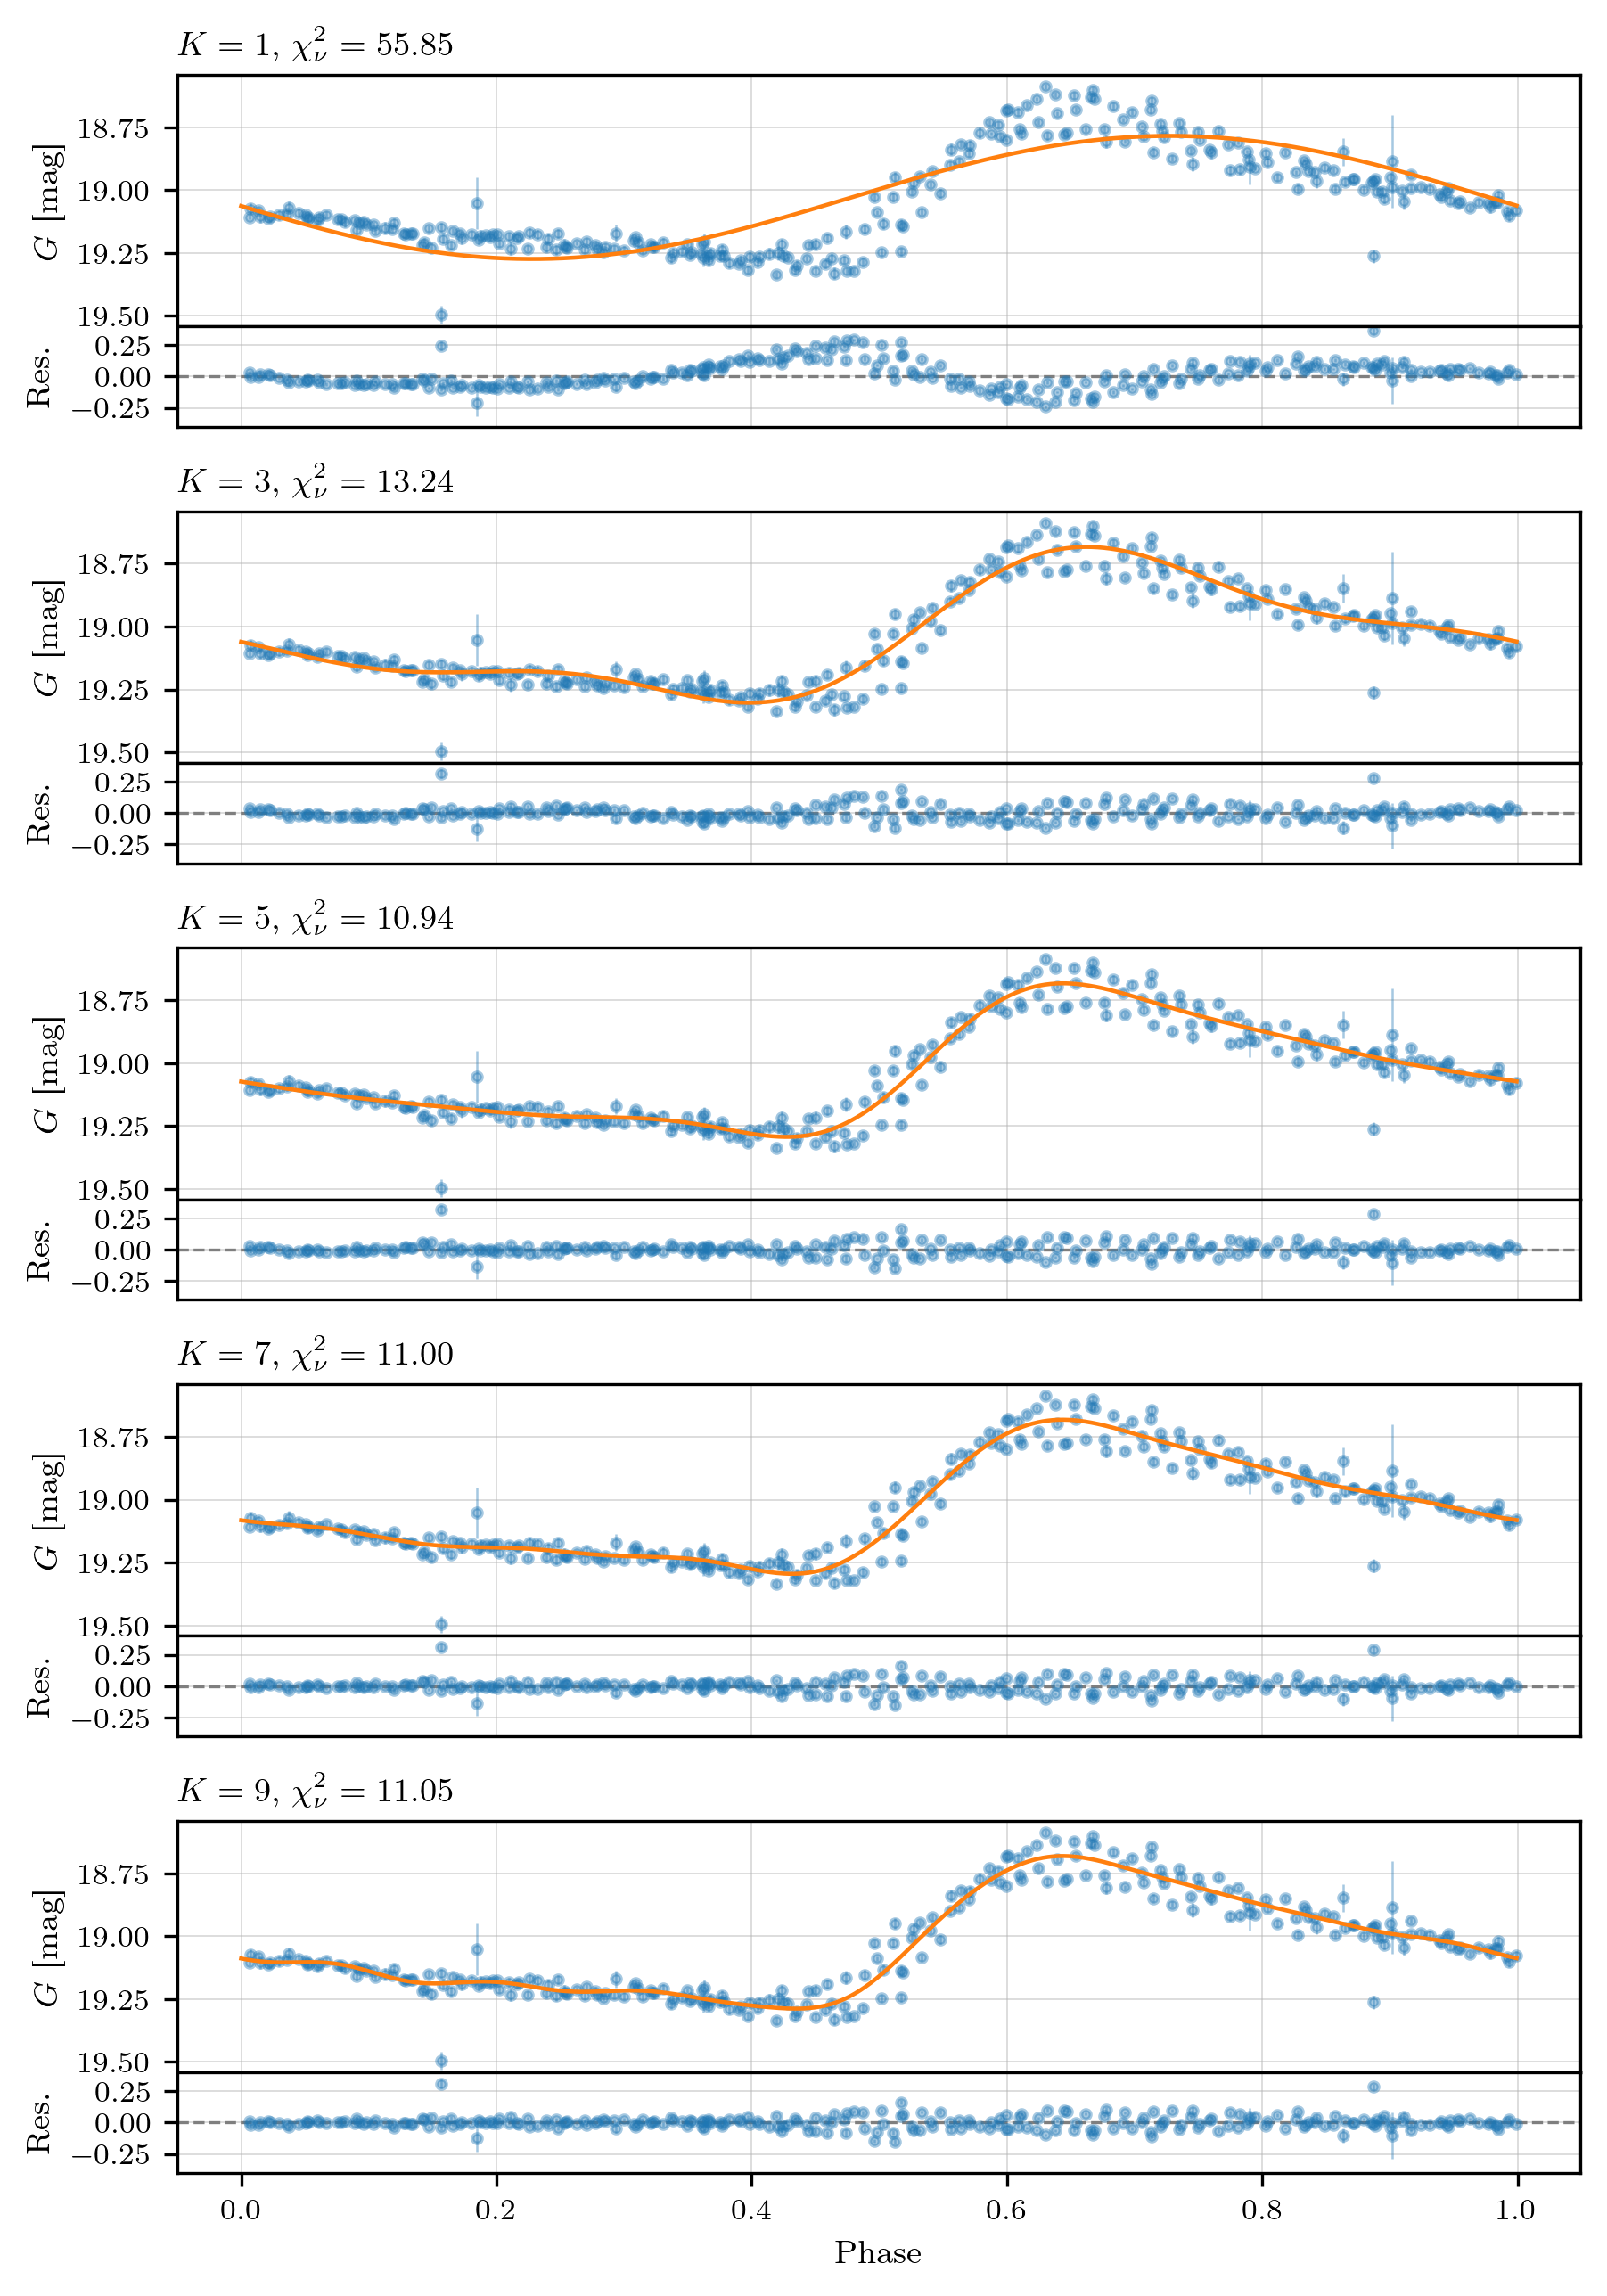

In [9]:
K_values = [1, 3, 5, 7, 9]

lightcurve = lightcurves[lightcurves["source_id"] == TARGET_ID]

axes = plot_fourier_harmonic_fits(lightcurve, K_values)
plt.show()


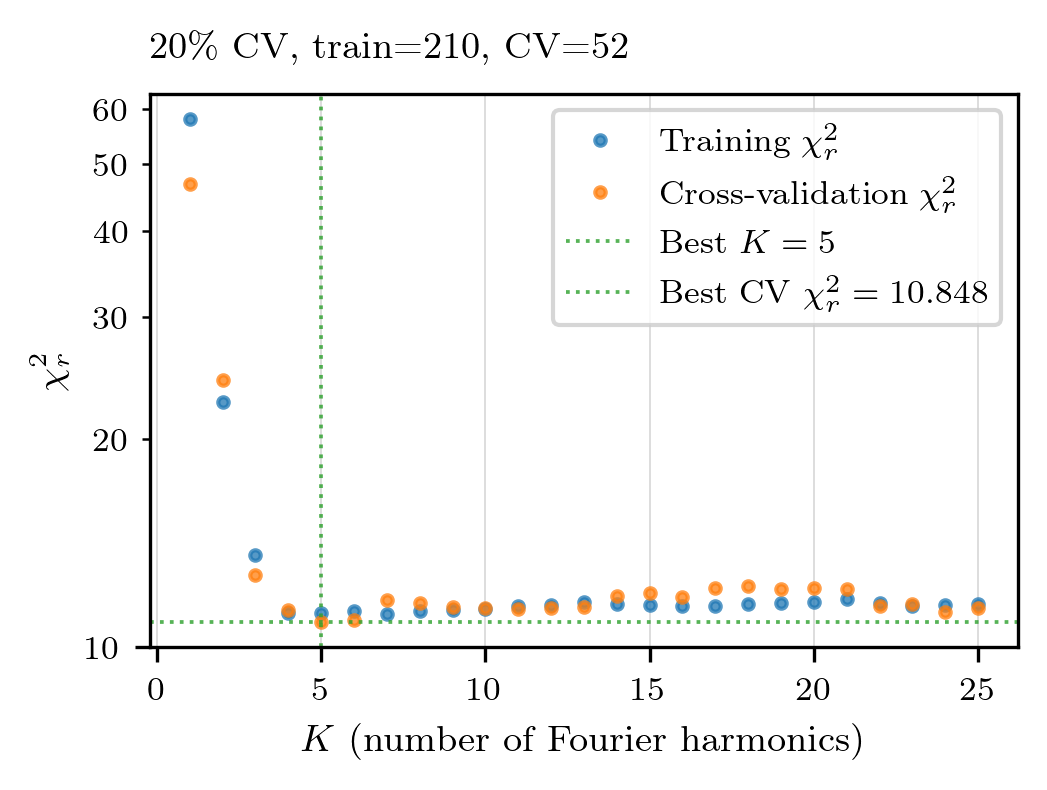

In [10]:
cross_validation_res = cross_validate_harmonics(lightcurve)
best_K = cross_validation_res.best_K
period_ls = cross_validation_res.period

train_lightcurve = lightcurve[cross_validation_res.train_idx]
cv_lightcurve = lightcurve[cross_validation_res.cv_idx]

low_K = cross_validation_res.Ks[0]
high_K = cross_validation_res.Ks[-1]

low_fit = fourier_fit(train_lightcurve, period_ls, low_K)
best_fit = fourier_fit(train_lightcurve, period_ls, best_K)
high_fit = fourier_fit(train_lightcurve, period_ls, high_K)

ax = plot_fourier_cross_validation(cross_validation_res)
plt.show()


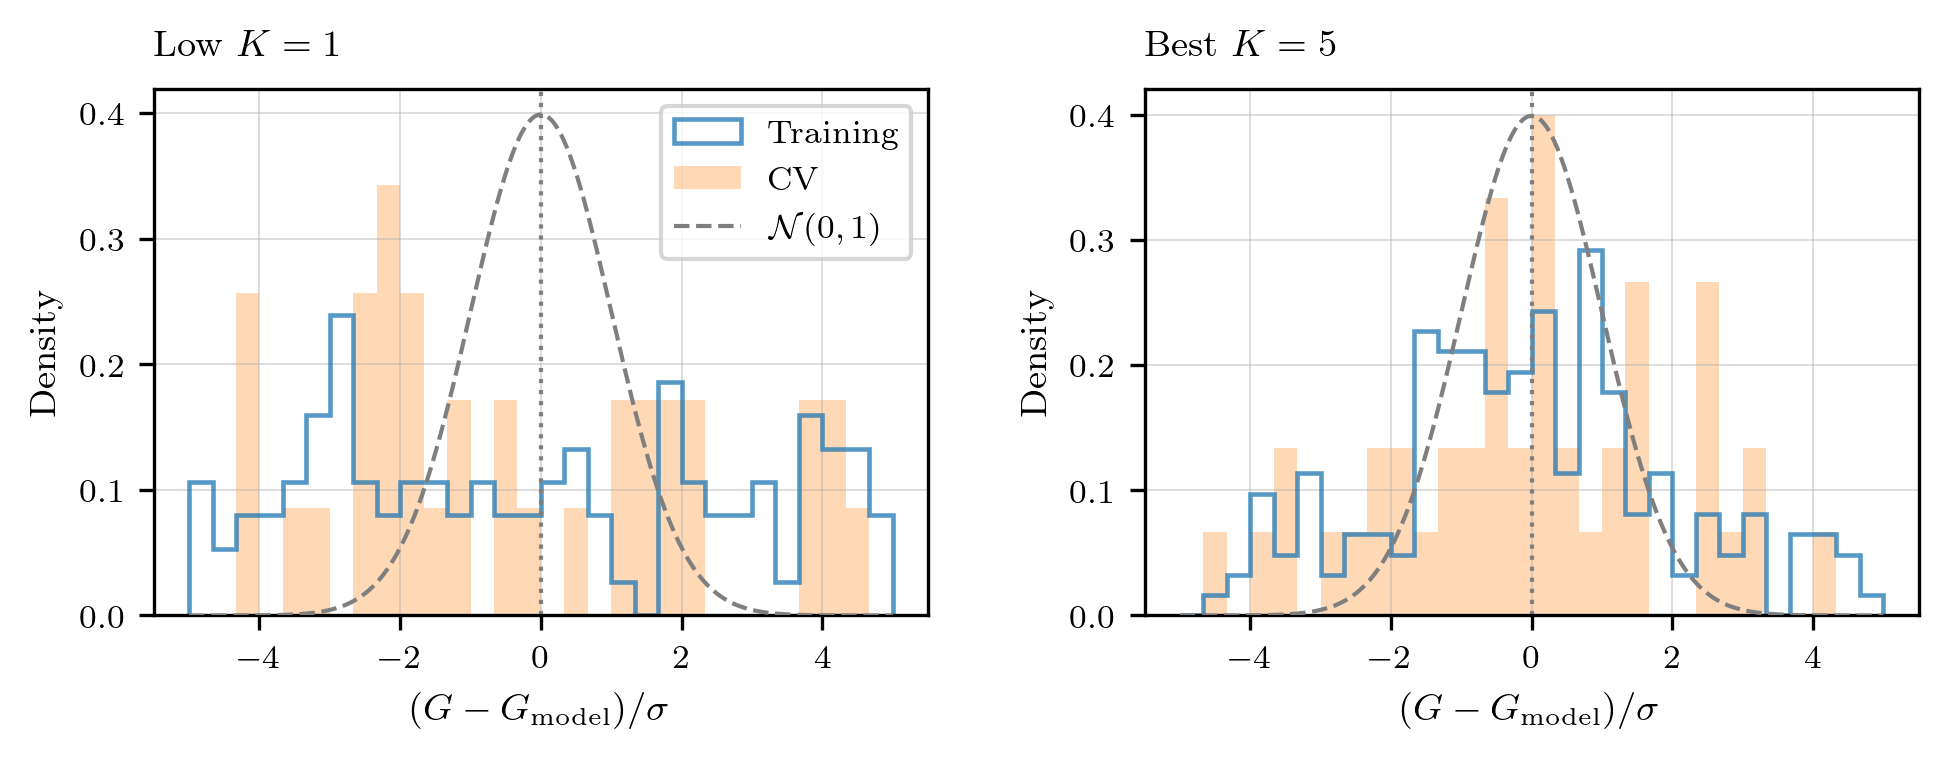

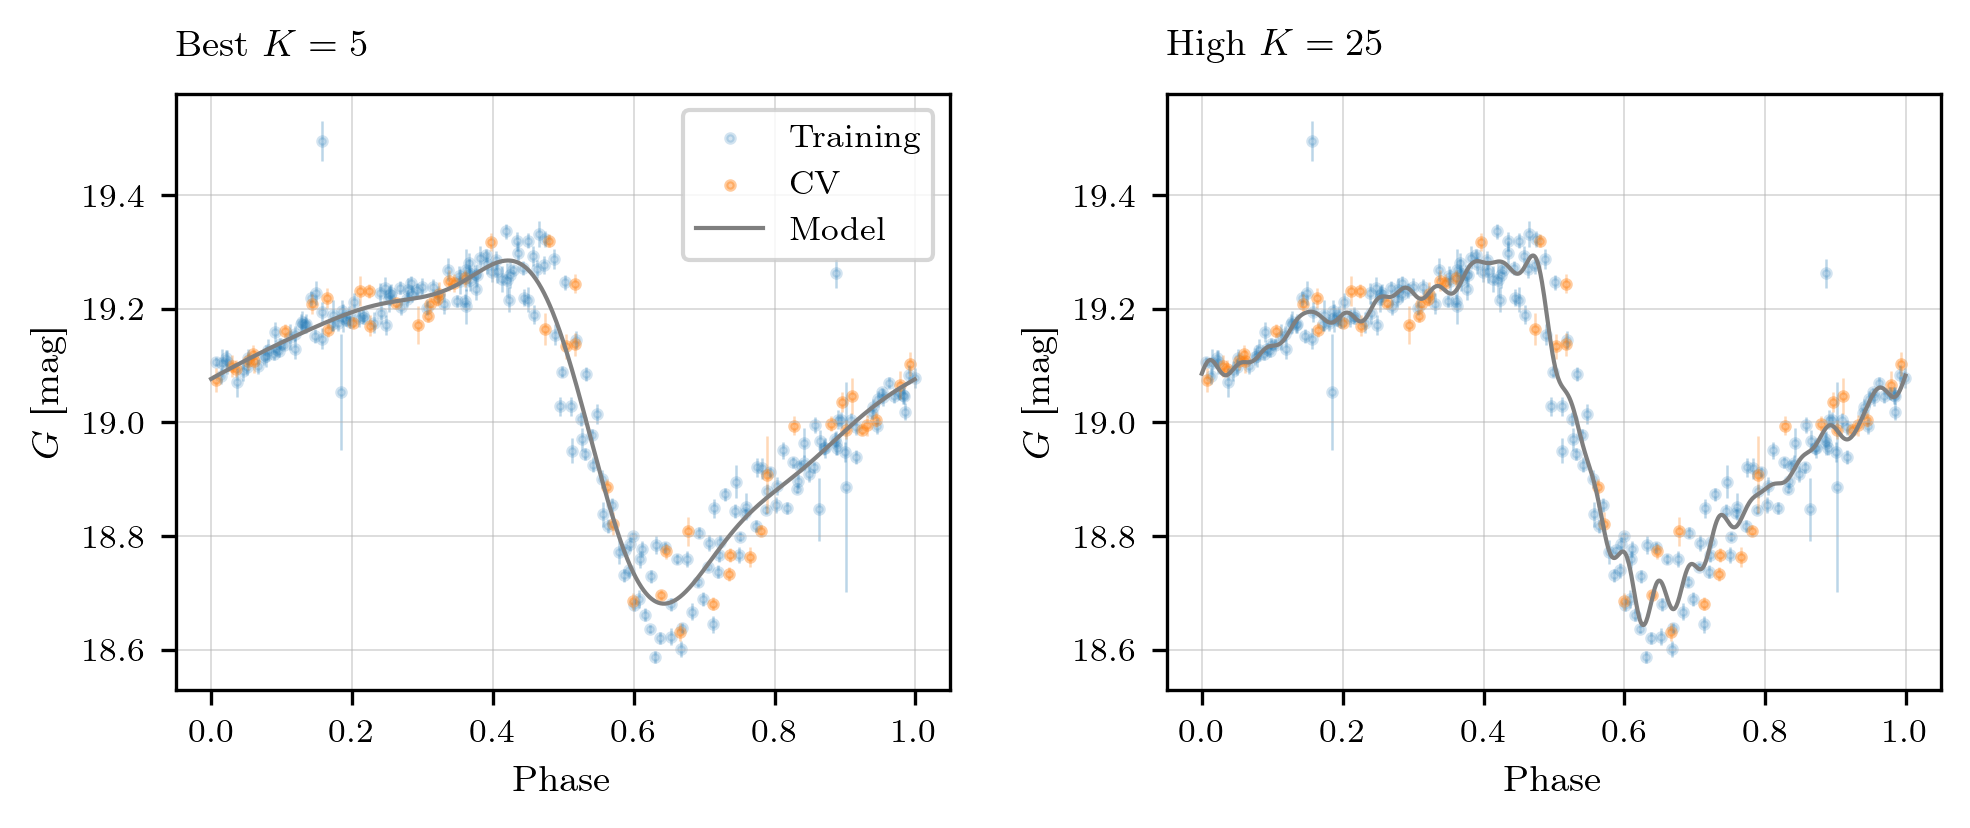

In [11]:
axes = plot_fourier_cv_normalized_residual_histograms(train_lightcurve, cv_lightcurve, low_fit, best_fit)
plt.show()

axes = plot_fourier_cv_phase_comparison(train_lightcurve, cv_lightcurve, best_fit, high_fit)
plt.show()



## Cross-Validation Diagnostic Discussion

The idea of choosing harmonic order by out-of-sample performance is standard machine-learning logic, but the exact implementation used here is a **practical heuristic** rather than a canonical RR Lyrae method. The repository function `cross_validate_harmonics(...)` uses the source's `period_ls`, generates one fixed random 80/20 train/CV split with RNG seed `42`, scans `K = 1,\ldots,25`, and evaluates reduced $\chi^2$ on both the training and validation subsets. The goal is simple: pick a harmonic order that captures real light-curve structure without rewarding unnecessary wiggles.

That means the figure should be read as a **single-split model-selection diagnostic**, not as a fully uncertainty-quantified estimate of the “true” optimal $K$. A different random split could change the detailed curve, and there is no repeated-CV or Bayesian model-averaging step here. The finite upper limit `K = 25` is also an implementation choice: it is high enough to show clear underfitting-to-overfitting behavior for these Gaia light curves, but it is not derived from first principles.

The low-$K$ histogram shows the classic underfitting regime. When the Fourier model is too simple, both the training and validation residuals remain broader than the reference $\mathcal{N}(0,1)$ curve because genuine light-curve structure is being left in the residuals. As $K$ increases toward the validation minimum, the model becomes flexible enough to capture the dominant astrophysical shape, and the training and validation residual distributions move closer together.

The high-$K$ phase-folded comparison then illustrates overfitting. Once too many harmonics are added, the training-set curve develops extra structure and follows the training points more aggressively, but the held-out points do not improve comparably. The validation metric therefore worsens even though the training fit looks more elaborate. In this notebook, the “best” harmonic order should be interpreted in that pragmatic sense: it is the lowest-complexity model that performs best on one held-out subset of the available Gaia epochs.

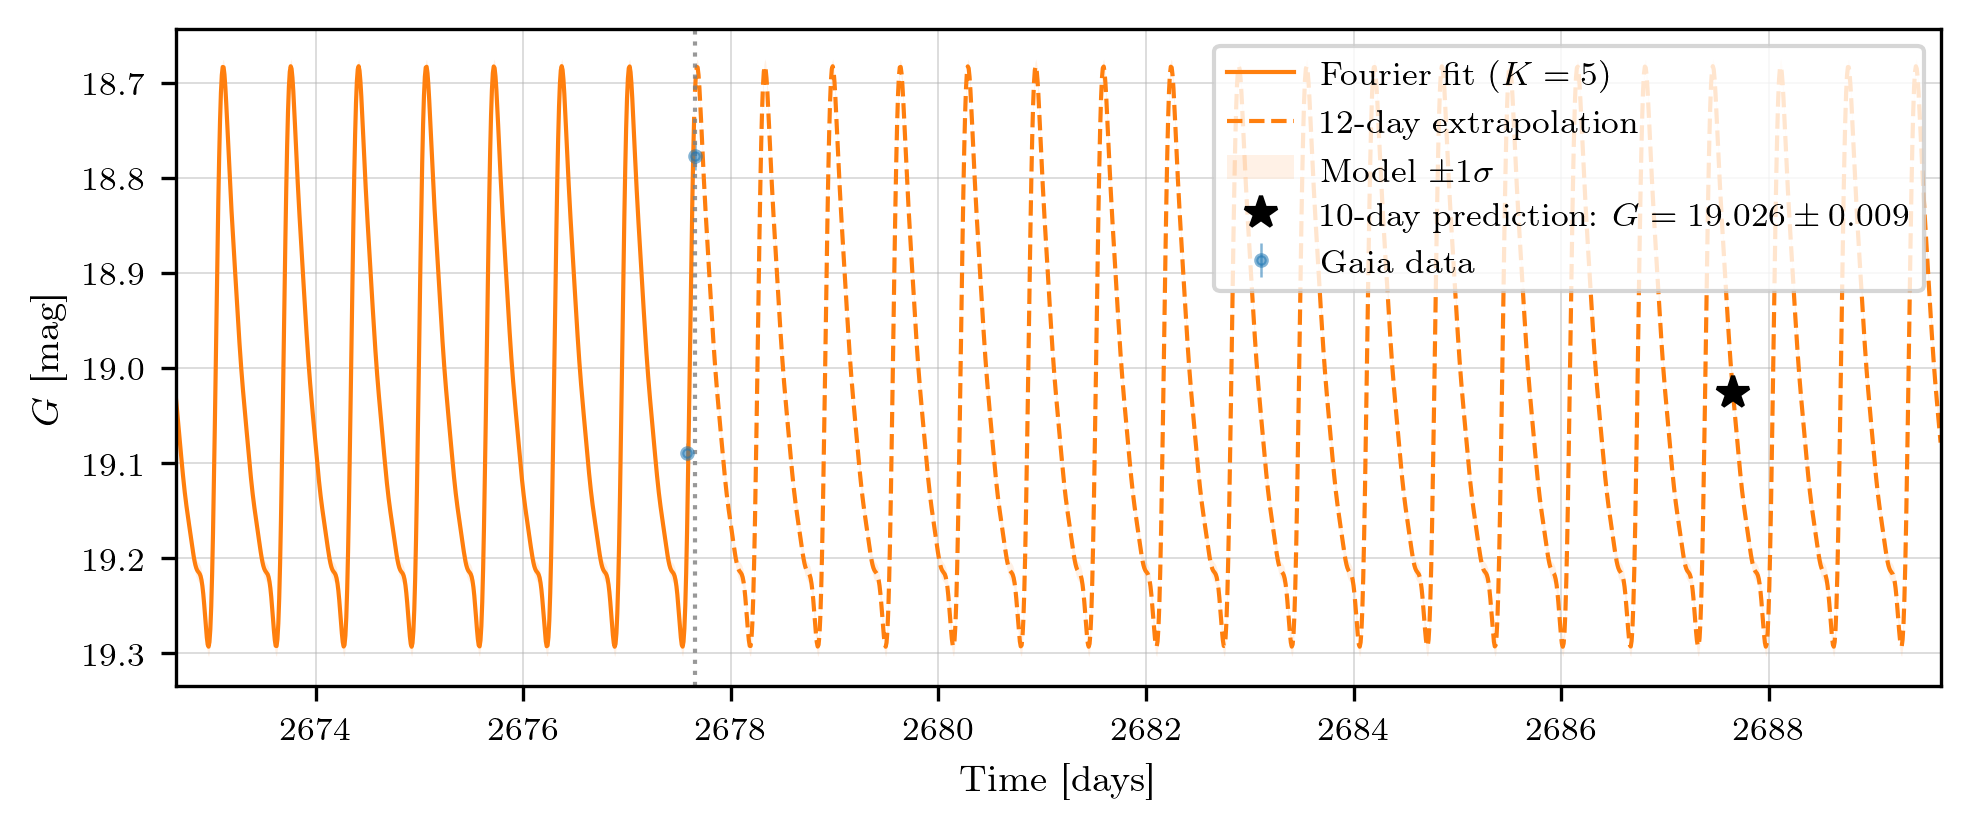

In [12]:
fit = fourier_fit(lightcurve, period_ls, best_K)
ax = plot_fourier_extrapolation(cross_validation_res, fit)
plt.show()


## What the 10-Day Extrapolation Means

The extrapolation panel is a demonstration of what a fitted one-period Fourier template predicts **beyond the observed time span**. The helper `predict_future_magnitude(fit)` evaluates the model exactly 10 days after the last observed Gaia epoch and reports the formal uncertainty from the fixed-$(P,K)$ coefficient covariance.

This is mathematically straightforward but astrophysically limited. For a strictly periodic, single-mode RR Lyrae star with a stable shape and a well-determined period, evaluating the fitted template 10 days later is a reasonable illustrative forecast. But it is not a general forecasting framework. The extrapolation can fail if the adopted period is slightly wrong, if the star is modulated, if it is genuinely multiperiodic, or if the finite-order Fourier model does not capture the true light-curve shape. The plot should therefore be read as a stress test of the one-period model, not as a production-quality predictor of future Gaia magnitudes.

## Formal Fourier-Fit Uncertainty at Fixed $(P, K)$

Once the notebook has chosen a working period $P$ and harmonic order $K$, the Fourier light-curve model is treated as **fixed in structure**:

$$
m(t) = \beta_0 + \sum_{k=1}^{K}\left[a_k\cos(k\omega t) + b_k\sin(k\omega t)\right], \qquad \omega = \frac{2\pi}{P}.
$$

At that point the problem is linear in the coefficient vector
$$
\boldsymbol{\beta} = (\beta_0, a_1, b_1, \ldots, a_K, b_K)^T,
$$
so the uncertainty analysis is the standard weighted least-squares calculation. If the measured magnitudes are collected into a data vector $\mathbf{y}$ and the design matrix $X$ contains the constant, cosine, and sine basis functions evaluated at the observed epochs, then the notebook solves for the best-fit coefficients by minimizing

$$
\chi^2 = \sum_i \frac{(y_i - (X\boldsymbol{\beta})_i)^2}{\sigma_i^2},
$$

where $\sigma_i = \mathtt{g\_transit\_mag\_err}_i$ are the Gaia epoch-level magnitude errors. In matrix form, with $W = \mathrm{diag}(1/\sigma_i^2)$,

$$
\hat{\boldsymbol{\beta}} = (X^T W X)^{-1} X^T W \mathbf{y}.
$$

The formal coefficient covariance is then

$$
C_{\beta} = (X^T W X)^{-1}.
$$

That covariance is what the code stores as `beta_cov`. In practice the implementation uses a pseudoinverse if the normal matrix is numerically singular, and then multiplies the covariance by $\max(\chi_\nu^2, 1)$ so that the reported coefficient errors are not overconfident when the fitted residual scatter already exceeds the nominal measurement noise.

Every later formal Fourier uncertainty in the notebook is derived from this same covariance matrix:

- For the fitted light curve at a new epoch $t_*$, let $\mathbf{x}_*$ be the corresponding row of the design matrix. Then the propagated variance of the predicted magnitude is
  $$
  \sigma_{\rm pred}^2(t_*) = \mathbf{x}_*^T C_{\beta} \mathbf{x}_*.
  $$
  This is what `predict_std()` computes, and it is the source of the shaded $\pm1\sigma$ band in the extrapolation plot.
- The 10-day forecast uncertainty from `predict_future_magnitude()` is exactly the same expression evaluated at the prediction epoch $t_{\rm last}+10$ days.
- The Fourier mean magnitude is obtained by transforming the fitted model into flux, averaging that flux over one cycle, and converting back to magnitudes. Its uncertainty is propagated by taking the gradient of that cycle-averaged magnitude with respect to $\boldsymbol{\beta}$ and contracting it with $C_{\beta}$.

This is a **formal conditional uncertainty**: it answers the question “how uncertain are the Fourier coefficients and derived quantities if the adopted $P$ and $K$ are correct and the quoted epoch errors are the only noise source?” It does **not** include uncertainty in the adopted period, alias ambiguity, RRd mode ambiguity, Blazhko-like modulation, or any other mismatch between a fixed one-period Fourier template and the real star. So when these formal errors are very small, the right interpretation is that the data constrain the coefficients tightly **within the assumed model**, not that the total astrophysical uncertainty is negligible.


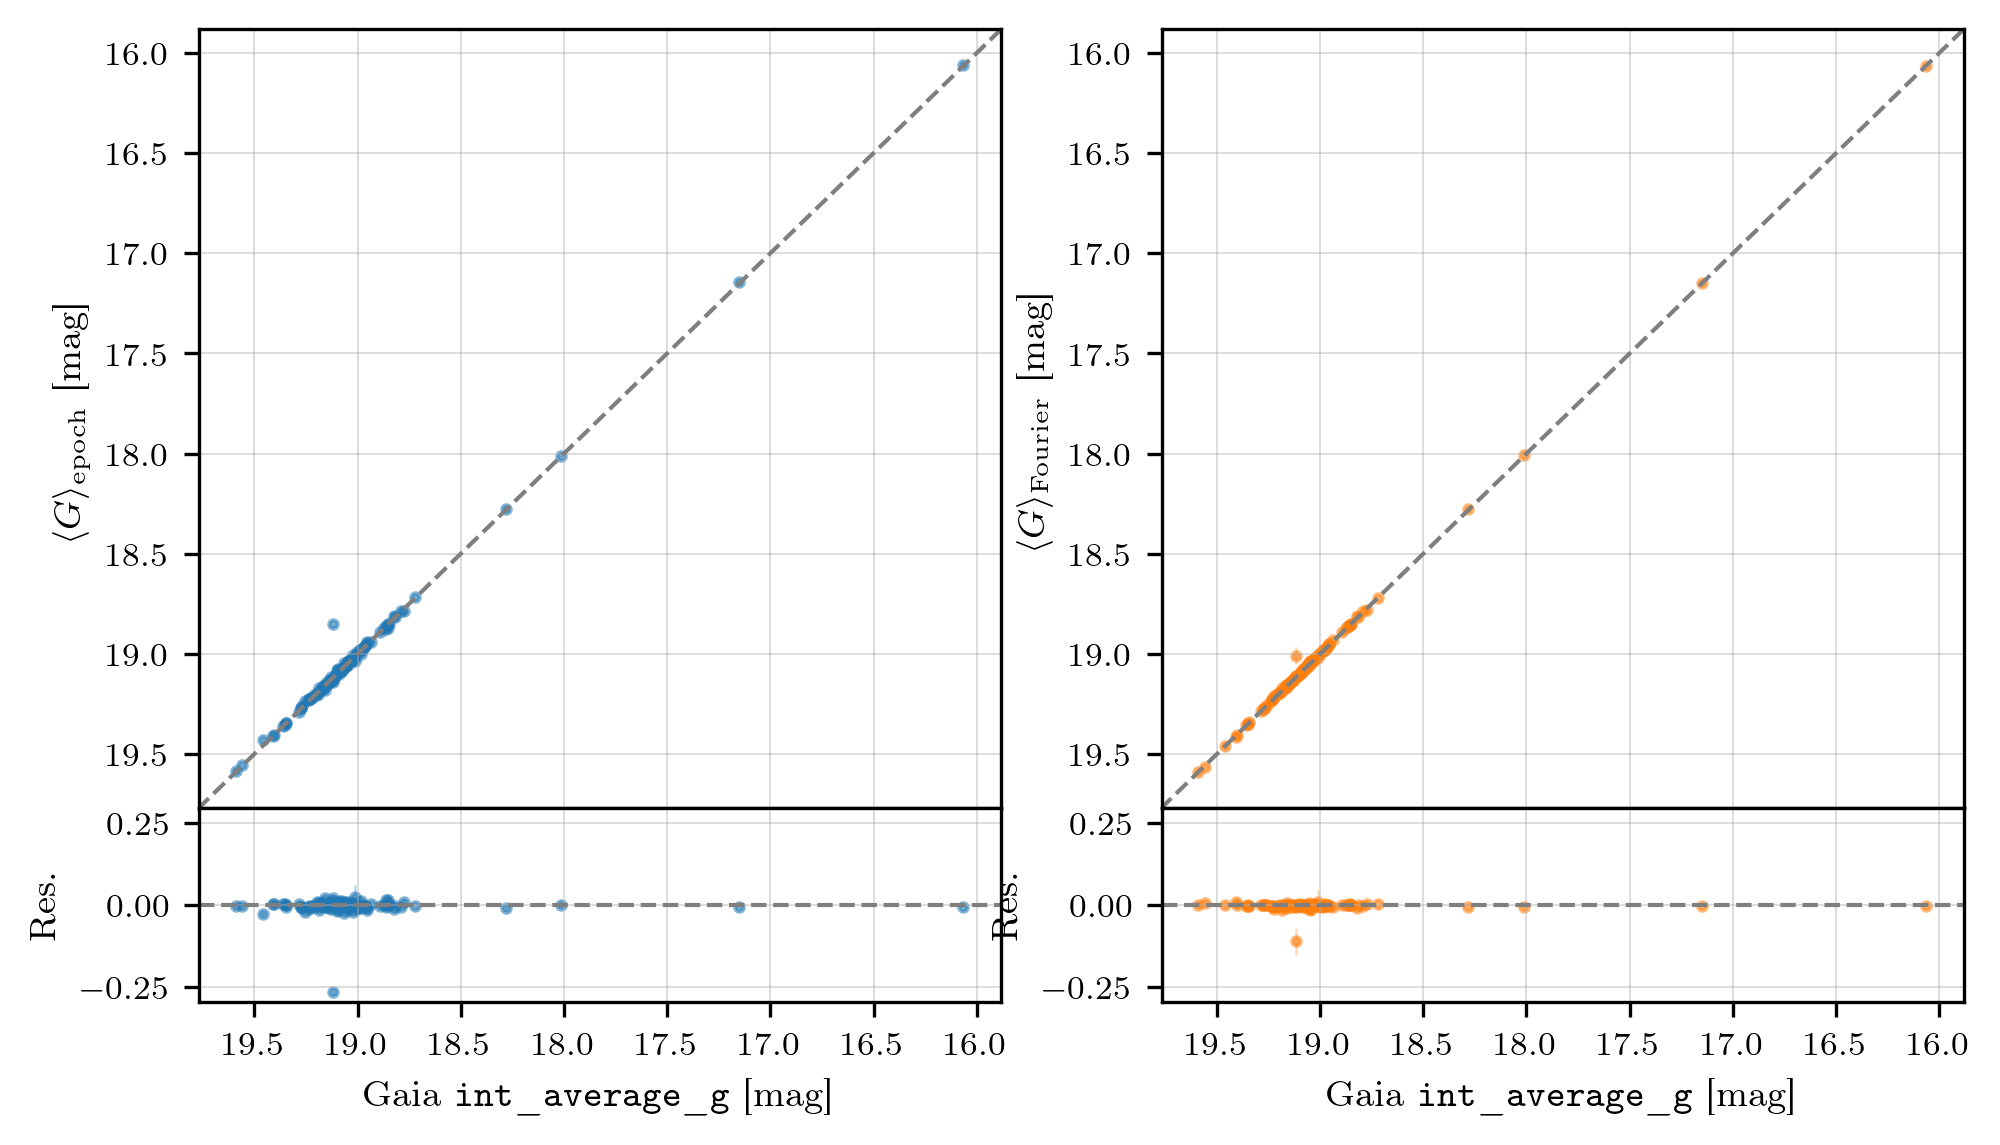

In [13]:
source_ids = summary["source_id"]

best_k_by_star = np.full(len(source_ids), np.nan, dtype=float)
fourier_mean_g = np.full(len(source_ids), np.nan, dtype=float)
fourier_mean_g_err = np.full(len(source_ids), np.nan, dtype=float)
for i, source_id in enumerate(source_ids):
    star = lightcurves[lightcurves["source_id"] == source_id]
    period_i = float(summary["best_period"][i])
    best_k_i = int(cross_validate_harmonics(star).best_K)
    fit = fourier_fit(star, period_i, best_k_i)
    best_k_by_star[i] = best_k_i
    fourier_mean_g[i] = fourier_mean_magnitude(fit)
    fourier_mean_g_err[i] = fourier_mean_magnitude_error(fit)

summary["best_K"] = best_k_by_star.astype(int)
summary["fourier_mean_apparent_g"] = fourier_mean_g
summary["fourier_mean_apparent_g_err"] = fourier_mean_g_err

axes = plot_mean_g_catalog_comparison(summary)
plt.show()


## Mean-Magnitude Comparison Discussion

The Gaia catalog quantity `int_average_g` is an **intensity-averaged** magnitude, so the most like-for-like comparison is the Fourier-based estimate that also averages the model flux over a full pulsation cycle before converting back to magnitudes. By contrast, the direct estimate from part (3) uses only the observed epochs. Even though that average is correctly performed in flux space, it can still be biased when the phase sampling is uneven and some parts of the light curve are over-represented.

The important implementation detail here is that the notebook does **not** use one global harmonic order for all stars. Instead, inside the per-star loop it recomputes `best_K = cross_validate_harmonics(star).best_K` for each source, using that source's own `period_ls`. The subsequent Fourier mean is then computed from the fit at that star's adopted period and recomputed harmonic order. This is a much more defensible procedure than forcing every source to share the single `best_K` obtained from one demonstration light curve.

For this run, the part (3) direct flux-space mean gives an RMS residual of **0.0282 mag** and a median absolute residual of **0.0053 mag** relative to Gaia `int_average_g`. The Fourier-based mean, using the cross-validated harmonic order selected separately for each star, improves those to an RMS residual of **0.0147 mag** and a median absolute residual of **0.0017 mag**. That is roughly a factor of two improvement in RMS and about a factor of three improvement in the median absolute residual.

This improvement has a clear physical interpretation. A fitted Fourier template uses the observed epochs to reconstruct the entire cycle, so it can compensate for the fact that the Gaia visits do not sample all phases equally. The direct epoch-average cannot do that; it simply averages whatever phases happened to be observed. The Fourier mean is therefore expected to track the true cycle-averaged flux more closely when the model is adequate.

The quoted Fourier mean uncertainties here are the **formal fixed-$(P,K)$ uncertainties** returned by `fourier_mean_magnitude_error(fit)`. They come only from propagating the fitted coefficient covariance into the cycle-averaged flux integral. They do not include uncertainty in the adopted period, uncertainty in the model family, or astrophysical departures from a strictly repeating one-period light curve. So if individual stars still appear as outliers relative to Gaia `int_average_g`, the likely causes are imperfect periods, limited harmonic complexity, or genuinely more complicated variability such as multi-mode pulsation or modulation.